# H-1B 2024 Hadoop MapReduce Analysis

This notebook analyzes the output of a Hadoop MapReduce job that processed
the 2024 H-1B Labor Condition Application (LCA) data.

We use the MapReduce output stored in `results/h1b2024_multi/part-r-00000`
to answer four questions:

1. How do wages differ between **tech** vs **non-tech** occupations?
2. For which occupations do H-1B workers earn the most in 2024?
3. Which states rely most heavily on H-1B workers in 2024?
4. How often is the worksite in a different state than the employer?


In [1]:
!pip3 install pandas matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 32.6 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 33.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [2]:
import pandas as pd

# Optional plotting (if you want charts)
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 80)


In [3]:
# Path to the MapReduce output you copied from HDFS
output_path = "../results/h1b2024_multi/part-r-00000"

df = pd.read_csv(
    output_path,
    sep="\t",
    header=None,
    names=["key", "total_workers", "avg_annual_wage"]
)

df.head()


,key,total_workers,avg_annual_wage
0,CAT|NON_TECH,458535,223900.76
1,CAT|TECH,808142,197141.57
2,FLOW|AK->AK,701,81435.23
3,FLOW|AK->FL,2,123080.25
4,FLOW|AK->HI,3,86920.00


In [4]:
# Split "key" into a type prefix and the rest
key_split = df["key"].str.split("|", n=1, expand=True)
df["key_type"] = key_split[0]
df["key_rest"] = key_split[1]

df.head()


,key,total_workers,avg_annual_wage,key_type,key_rest
0,CAT|NON_TECH,458535,223900.76,CAT,NON_TECH
1,CAT|TECH,808142,197141.57,CAT,TECH
2,FLOW|AK->AK,701,81435.23,FLOW,AK->AK
3,FLOW|AK->FL,2,123080.25,FLOW,AK->FL
4,FLOW|AK->HI,3,86920.00,FLOW,AK->HI


In [5]:
# 1) Tech vs non-tech
cat_df = df[df["key_type"] == "CAT"].copy()
cat_df["category"] = cat_df["key_rest"]

# 2) Occupations
soc_df = df[df["key_type"] == "SOC"].copy()
soc_split = soc_df["key_rest"].str.split("|", n=1, expand=True)
soc_df["soc_code"] = soc_split[0]
soc_df["soc_title"] = soc_split[1]

# 3) States
state_df = df[df["key_type"] == "STATE"].copy()
state_df["state"] = state_df["key_rest"]

# 4) Employer->Worksite flows
flow_df = df[df["key_type"] == "FLOW"].copy()
flow_split = flow_df["key_rest"].str.split("->", n=1, expand=True)
flow_df["employer_state"] = flow_split[0]
flow_df["worksite_state"] = flow_split[1]

cat_df, soc_df.head(), state_df.head(), flow_df.head()


(            key  total_workers  avg_annual_wage key_type  key_rest  category
 0  CAT|NON_TECH         458535        223900.76      CAT  NON_TECH  NON_TECH
 1      CAT|TECH         808142        197141.57      CAT      TECH      TECH,
                                                  key  total_workers  \
 1922                 SOC|11-1011.00|Chief Executives            902   
 1923    SOC|11-1011.03|Chief Sustainability Officers             15   
 1924                    SOC|11-1011|Chief Executives              7   
 1925      SOC|11-1021.00|General Operations Managers              2   
 1926  SOC|11-1021.00|General and Operations Managers           2859   
 
       avg_annual_wage key_type                                    key_rest  \
 1922       1224669.33      SOC                 11-1011.00|Chief Executives   
 1923        247896.90      SOC    11-1011.03|Chief Sustainability Officers   
 1924        420714.29      SOC                    11-1011|Chief Executives   
 1925        35

## 1. Tech vs Non-Tech Wages

We classify occupations as **TECH** if the SOC code starts with `15-`
(Computer & Mathematical occupations). Everything else is **NON_TECH**.

We compare:

- Total H-1B workers
- Average annual wage
for TECH vs NON_TECH in 2024.


In [6]:
cat_df[["category", "total_workers", "avg_annual_wage"]]


,category,total_workers,avg_annual_wage
0,NON_TECH,458535,223900.76
1,TECH,808142,197141.57


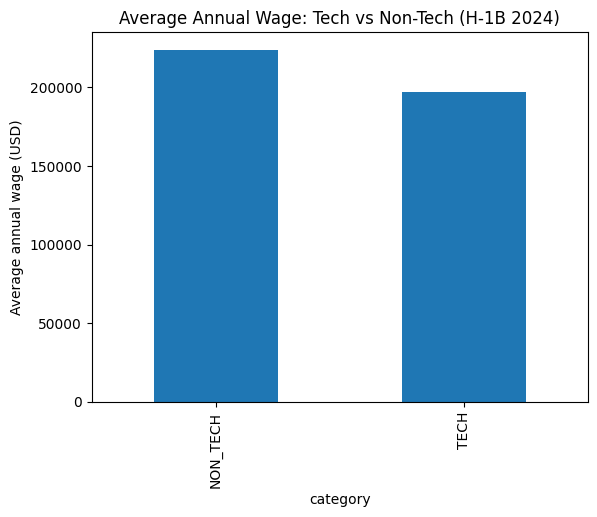

In [7]:
cat_df.set_index("category")["avg_annual_wage"].plot(
    kind="bar",
    title="Average Annual Wage: Tech vs Non-Tech (H-1B 2024)"
)
plt.ylabel("Average annual wage (USD)")
plt.show()


## 2. Highest-Paid Occupations

We look at occupations (`SOC_CODE`, `SOC_TITLE`) with a minimum
number of workers (e.g. at least 100 workers) and rank them by
average annual wage.

This avoids small, noisy categories with only a few workers.


In [8]:
# Choose a minimum worker threshold (you can adjust this)
MIN_WORKERS = 100

soc_filtered = soc_df[soc_df["total_workers"] >= MIN_WORKERS].copy()

top_occupations = soc_filtered.sort_values(
    by="avg_annual_wage",
    ascending=False
).head(20)

top_occupations[["soc_code", "soc_title", "total_workers", "avg_annual_wage"]]


,soc_code,soc_title,total_workers,avg_annual_wage
2907,29-1223.00,Psychiatrists,487,1894717.79
2790,27-1014.00,Special Effects Artists and Animators,415,1645385.91
1922,11-1011.00,Chief Executives,902,1224669.33
2664,25-1041.00,"Agricultural Sciences Teachers, Postsecondary",205,1032163.80
2848,29-1031.00,Dietitians and Nutritionists,172,1023144.39
1957,11-3031.00,Financial Managers,2409,1014878.33
2915,29-1229.02,Hospitalists,2084,992618.99
2653,25-1011.00,"Business Teachers, Postsecondary",1745,972727.39
2196,15-1243.01,Data Warehousing Specialists,1554,889074.01
2643,23-1011.00,Lawyers,3166,843766.53


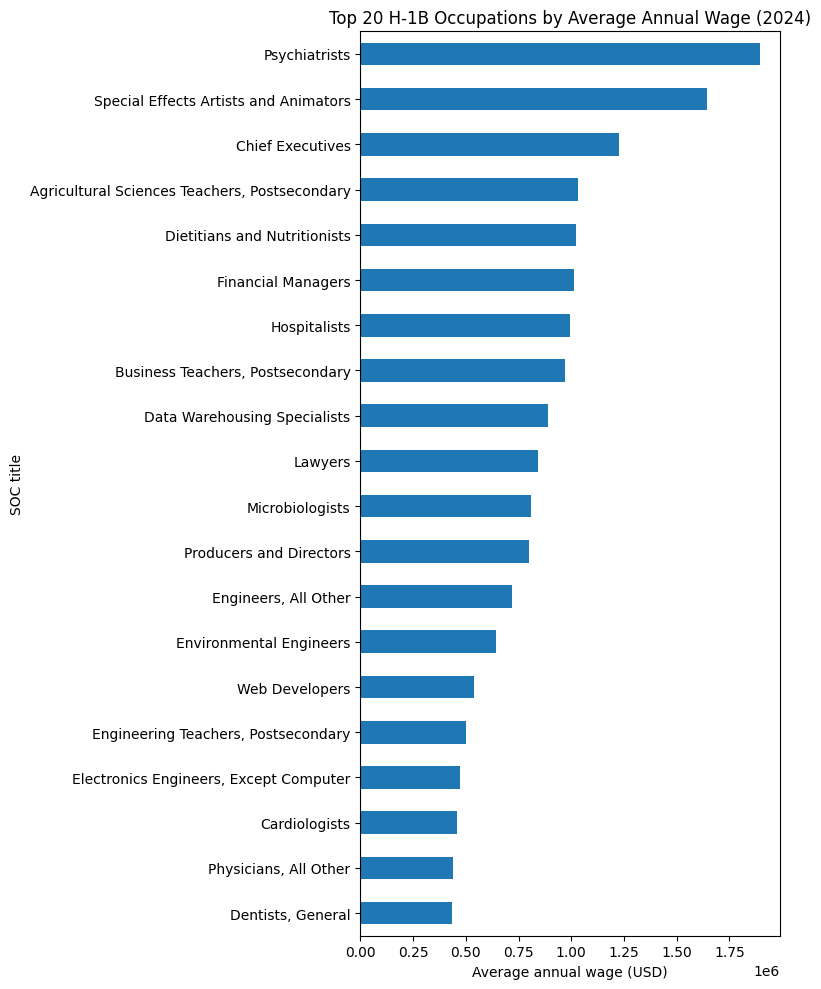

In [9]:
top_occupations.plot(
    x="soc_title",
    y="avg_annual_wage",
    kind="barh",
    figsize=(8, 10),
    title="Top 20 H-1B Occupations by Average Annual Wage (2024)",
    legend=False
)
plt.xlabel("Average annual wage (USD)")
plt.ylabel("SOC title")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 3. States Relying Most on H-1B Workers

We rank states by total number of H-1B workers (from TOTAL_WORKER_POSITIONS).
This gives a view of which states rely most heavily on H-1B labor.

We also show the average annual wage in each state.


In [10]:
# Sort by total workers
state_rank = state_df.sort_values(
    by="total_workers",
    ascending=False
).reset_index(drop=True)

top_states = state_rank.head(20)
top_states[["state", "total_workers", "avg_annual_wage"]]


,state,total_workers,avg_annual_wage
0,CA,305646,250266.59
1,TX,180241,204659.27
2,WA,133394,159366.81
3,NY,99514,237868.32
4,NJ,49219,192113.57
5,IL,47732,156382.91
6,NC,46359,180567.50
7,MA,41243,223295.52
8,GA,39219,200462.10
9,FL,33480,207181.97


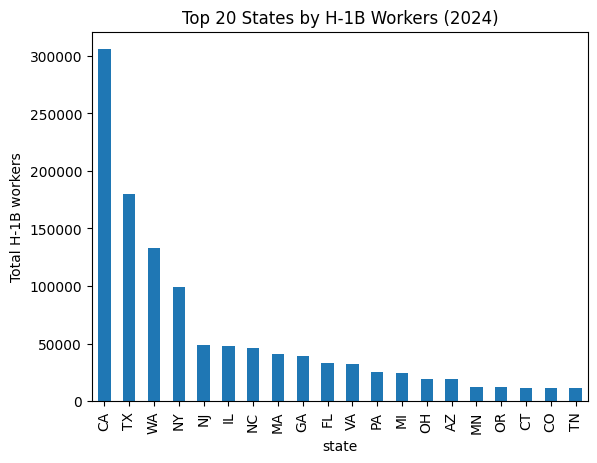

In [11]:
top_states.plot(
    x="state",
    y="total_workers",
    kind="bar",
    title="Top 20 States by H-1B Workers (2024)",
    legend=False
)
plt.ylabel("Total H-1B workers")
plt.show()


## 4. Employer State vs Worksite State (Flows)

We analyze how often workers are placed in a *different* state than the
employer's state – a proxy for remote work or outsourcing.

We compute:

- Total workers where `EMPLOYER_STATE == WORKSITE_STATE`
- Total workers where `EMPLOYER_STATE != WORKSITE_STATE`
- The percentage of cross-state placements
- The top state-to-state flows by worker count


In [12]:
flow_df["same_state"] = flow_df["employer_state"] == flow_df["worksite_state"]

same_state_workers = flow_df[flow_df["same_state"]]["total_workers"].sum()
diff_state_workers = flow_df[~flow_df["same_state"]]["total_workers"].sum()
total_workers_flows = same_state_workers + diff_state_workers

same_pct = 100 * same_state_workers / total_workers_flows
diff_pct = 100 * diff_state_workers / total_workers_flows

same_state_workers, diff_state_workers, total_workers_flows, same_pct, diff_pct


(np.int64(630633),
 np.int64(635893),
 np.int64(1266526),
 np.float64(49.79234536045845),
 np.float64(50.20765463954155))

In [13]:
# Only flows where employer_state != worksite_state
cross_flows = flow_df[flow_df["employer_state"] != flow_df["worksite_state"]].copy()

top_flows = cross_flows.sort_values(
    by="total_workers",
    ascending=False
).head(20)

top_flows[["employer_state", "worksite_state", "total_workers", "avg_annual_wage"]]


,employer_state,worksite_state,total_workers,avg_annual_wage
173,CA,TX,32161,188066.91
1796,WA,CA,28923,157682.02
1835,WA,TX,18772,127558.99
178,CA,WA,18249,283770.73
1626,TX,CA,15812,183880.90
1193,NJ,TX,13527,113963.15
1183,NJ,NY,12816,119094.87
1296,NY,TX,12663,172806.34
1163,NJ,IL,11630,149675.10
1826,WA,NY,11388,139427.96


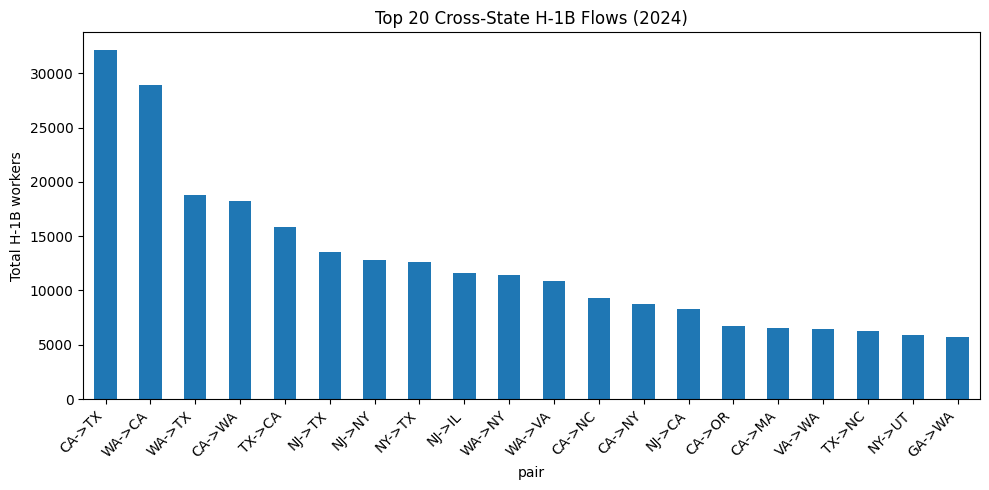

In [14]:
top_flows["pair"] = top_flows["employer_state"] + "->" + top_flows["worksite_state"]

top_flows.plot(
    x="pair",
    y="total_workers",
    kind="bar",
    figsize=(10, 5),
    title="Top 20 Cross-State H-1B Flows (2024)",
    legend=False
)
plt.ylabel("Total H-1B workers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
